# Capstone Function 2
Imagine a black box, or a mystery ML model, that takes two numbers as input, and returns a log-likelihood score. Goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.
To tackle this, you use Bayesian Optimisation, which selects the next inputs based on what it has learnt so far.  Balances exploration iwth exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

 Input | Output | Goal |
|-------|--------|------|
| 2D Array (10, 2) | 1D Array (10, ) | Maximise |

### Step 1: Import Required Libraries

Import necessary libraries for Bayesian Optimization, data handling, and visualization.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

### Step 2: Load and Display Initial Data

Load the initial input and output data for the noisy log-likelihood optimization problem.

In [ ]:
# Load initial data
X_init = np.load('../../data/f2/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f2/updated_outputs - Week 4.npy')

# Display data characteristics
print("Initial Data Summary:")
print(f"Input shape: {X_init.shape}")
print(f"Output shape: {y_init.shape}")
print(f"\nInput range: [{X_init.min():.4f}, {X_init.max():.4f}]")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")
print(f"Output mean: {y_init.mean():.6f}")
print(f"Output std: {y_init.std():.6f}")
print(f"\nBest observed value: {y_init.max():.6f}")
print(f"Best input location: {X_init[y_init.argmax()]}")

# Display first few samples
print(f"\nFirst 5 samples:")
for i in range(min(5, len(X_init))):
    print(f"  X[{i}] = {X_init[i]}, y[{i}] = {y_init[i]:.6f}")

In [ ]:
# Visualize initial data points in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_init[:, 0], X_init[:, 1], c=y_init, s=200, cmap='viridis', edgecolors='black', linewidth=1.5)
plt.colorbar(scatter, label='Output Value (Log-Likelihood)')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Initial Data Points - Noisy Log-Likelihood Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the best point
best_idx = y_init.argmax()
plt.scatter(X_init[best_idx, 0], X_init[best_idx, 1], s=400, c='red', marker='*', edgecolors='black', linewidth=2, label=f'Best (y={y_init[best_idx]:.6f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Step 3: Define Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **Gaussian Process Kernel**: Matern 5/2 (BoTorch default)
   - **Why**: Robust to noise, which is critical for this noisy log-likelihood function
   - Twice differentiable, providing smooth predictions

2. **Acquisition Function**: Expected Improvement (EI)
   - **Why**: Handles noisy observations well by averaging over uncertainty
   - Good at avoiding local optima through exploration-exploitation balance
   - Well-suited for problems with multiple local peaks

3. **Number of Restarts for Acquisition Optimization**: 10
   - **Why**: Important for noisy functions to avoid getting stuck in local optima
   - Multiple restarts ensure robust acquisition function optimization

4. **Number of Raw Samples**: 512
   - **Why**: Thorough initial sampling to find good starting points
   - Helps navigate complex landscape with potential local maxima

5. **Input Bounds**: [0, 1.0] for all dimensions
   - **Why**: Required by submission format - all inputs must be in range [0, 1.0]

6. **Standardize Outputs**: Yes (automatic in SingleTaskGP)
   - **Why**: Critical for numerical stability with varying output scales
   - GP noise model learns appropriate noise level from data

In [ ]:
# Define hyperparameters
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]  # Number of dimensions
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)

NUM_RESTARTS = 10  # Number of restarts for acquisition function optimization
RAW_SAMPLES = 512  # Number of initial random samples for acquisition optimization

print("Hyperparameters:")
print(f"  Input bounds: [0, 1.0] for all {N_DIM} dimensions")
print(f"  Acquisition function: Expected Improvement (EI)")
print(f"  GP Kernel: Matern 5/2 (default)")
print(f"  Number of restarts: {NUM_RESTARTS}")
print(f"  Raw samples: {RAW_SAMPLES}")
print(f"  Output standardization: Yes (SingleTaskGP handles this)")

### Step 4: Build Gaussian Process Surrogate Model

Create and train a Gaussian Process model on the initial data. The GP learns patterns in the noisy observations.

In [ ]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")

# Create Gaussian Process model
gp_model = SingleTaskGP(X_train, y_train)

# Define the marginal log likelihood
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)

# Fit the GP model to the data
print("\nTraining Gaussian Process model...")
fit_gpytorch_mll(mll)
print("✓ Model training complete!")

# Display learned hyperparameters
print("\nLearned GP Hyperparameters:")
print(f"  Noise variance: {gp_model.likelihood.noise.item():.6f}")
# Check if covar_module has outputscale (ScaleKernel) or is base kernel directly
if hasattr(gp_model.covar_module, 'outputscale'):
    print(f"  Output scale: {gp_model.covar_module.outputscale.item():.6f}")
    print(f"  Length scales: {gp_model.covar_module.base_kernel.lengthscale.detach().numpy()}")
else:
    # Direct access to kernel lengthscale
    print(f"  Length scales: {gp_model.covar_module.lengthscale.detach().numpy()}")
print(f"\nNote: Noise variance estimates observational noise in the log-likelihood function")

### Step 5: Optimize Acquisition Function to Propose Next Sample

Use Expected Improvement to find the next most promising point to evaluate.

In [ ]:
# Create Expected Improvement acquisition function
best_f = y_train.max().item()
print(f"Best observed value: {best_f:.6f}")

EI = ExpectedImprovement(gp_model, best_f=best_f)

# Optimize the acquisition function
print("\nOptimizing acquisition function...")
candidate, acq_value = optimize_acqf(
    EI,
    bounds=BOUNDS,
    q=1,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Extract the proposed next point
next_point = candidate.detach().numpy()[0]
print("✓ Optimization complete!")
print(f"\nProposed next sample point:")
print(f"  X_next = {next_point}")
print(f"  Expected Improvement value: {acq_value.item():.6f}")

### Step 6: Visualize Surrogate Function

Visualize the GP mean prediction and uncertainty across the 2D search space.

In [ ]:
# Create a grid for visualization
n_grid = 50
x1_range = np.linspace(BOUNDS[0, 0].item(), BOUNDS[1, 0].item(), n_grid)
x2_range = np.linspace(BOUNDS[0, 1].item(), BOUNDS[1, 1].item(), n_grid)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
X_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
X_grid_torch = torch.tensor(X_grid, dtype=torch.float64)

# Get GP predictions
gp_model.eval()
with torch.no_grad():
    posterior = gp_model.posterior(X_grid_torch)
    mean = posterior.mean.numpy().reshape(n_grid, n_grid)
    std = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: GP Mean Prediction
im1 = axes[0].contourf(X1_grid, X2_grid, mean, levels=20, cmap='viridis')
axes[0].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[0].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('GP Mean Prediction', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
plt.colorbar(im1, ax=axes[0], label='Predicted Log-Likelihood')

# Plot 2: GP Uncertainty
im2 = axes[1].contourf(X1_grid, X2_grid, std, levels=20, cmap='plasma')
axes[1].scatter(X_init[:, 0], X_init[:, 1], c='white', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
axes[1].scatter(next_point[0], next_point[1], c='red', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point', zorder=6)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('GP Uncertainty (Std Dev)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
plt.colorbar(im2, ax=axes[1], label='Standard Deviation')

plt.tight_layout()
plt.show()

print(f"GP captures trends despite noise. Uncertainty highest in unexplored regions.")

### Step 7: Visualize Acquisition Function

Show the Expected Improvement values across the search space.

In [ ]:
# Compute Expected Improvement values across the grid
with torch.no_grad():
    ei_values = EI(X_grid_torch.unsqueeze(1)).numpy().reshape(n_grid, n_grid)

# Visualize Expected Improvement
plt.figure(figsize=(10, 8))
im = plt.contourf(X1_grid, X2_grid, ei_values, levels=20, cmap='hot')
plt.scatter(X_init[:, 0], X_init[:, 1], c='cyan', s=100, edgecolors='black', linewidth=2, label='Observed points', zorder=5)
plt.scatter(next_point[0], next_point[1], c='lime', s=300, marker='*', edgecolors='black', linewidth=2, label='Next point (max EI)', zorder=6)
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('Expected Improvement Acquisition Function', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EI balances exploring uncertain regions and exploiting promising areas.")

### Step 8: Track Optimization Progress

Monitor the best observed value over iterations.

In [ ]:
# Track the best value found so far at each iteration
best_observed = np.maximum.accumulate(y_init)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_observed) + 1), best_observed, 'b-o', linewidth=2, markersize=8, label='Best observed value')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Log-Likelihood', fontsize=12)
plt.title('Optimization Progress - Best Value Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Starting best value: {y_init.max():.6f}")
print(f"After {len(y_init)} initial samples, awaiting next evaluation...")
print(f"\nNext submission: {next_point}")

### Step 9: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
if acq_value.item() > 0.1:
    print("  → High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  → Moderate EI: Some exploration potential remains")
else:
    print("  → Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**Initial Submission Complete**

- Loaded 10 initial data points for noisy 2D log-likelihood optimization
- Built Gaussian Process surrogate model with Matern 5/2 kernel
- Model handles noisy observations through learned noise variance
- Used Expected Improvement acquisition function
- Proposed next sample point for evaluation
- Visualized surrogate function, uncertainty, and acquisition landscape

**Key Considerations for Noisy Function:**
- GP noise model captures observation uncertainty
- Multiple local optima require careful exploration
- Expected Improvement naturally handles noise through probabilistic predictions

**Next Steps:**
1. Submit the proposed point for evaluation
2. Receive the observation result
3. Add to dataset and retrain model
4. Propose next point (repeat process)

## Week 5 — Random Forest Surrogate

This section replaces the Gaussian Process surrogate with a **Random Forest** model for the log-likelihood estimation problem (f2).

**Why Random Forest for f2?**
- Handles noise well — individual trees may overfit, but the ensemble averages out noise
- No distributional assumptions about the objective function (unlike GP which assumes a Gaussian prior)
- Provides natural uncertainty estimates via variance across individual tree predictions
- Feature importance scores show which input dimensions matter most

**Acquisition Strategy:** Upper Confidence Bound (UCB) using tree-variance as uncertainty estimate.

### Step 1: Load Week 5 Data

Load the cumulative Week 5 data (15 total samples = initial + weekly submissions).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f2/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f2/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Input range:  [{X_w5.min():.6f}, {X_w5.max():.6f}]")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed value: {y_w5.max():.6f} at index {y_w5.argmax()}")
print(f"Best observed point: {X_w5[y_w5.argmax()]}")

Week 5 Data: 15 samples, 2 dimensions
Input range:  [0.028698, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]


### Step 2: Random Forest Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 100**: Number of trees in the forest. With only 15 samples, 100 trees provides sufficient ensemble diversity without excessive computation.

2. **max_depth = 5**: Maximum tree depth. Capped at 5 to prevent overfitting on just 15 samples. Each leaf should contain at least 2-3 samples.

3. **min_samples_split = 3**: Minimum samples required to split a node. Set to 3 to ensure no split creates nodes with too few samples.

4. **min_samples_leaf = 2**: Minimum samples in a leaf node. Set to 2 to prevent extreme predictions from single-sample leaves.

5. **random_state = 42**: Fixed seed for reproducibility.

6. **oob_score = True**: Out-of-bag score provides a free validation metric — each tree's OOB samples approximate hold-out error.

7. **UCB kappa = 2.0**: Exploration parameter for tree-variance-based uncertainty. Tree std is well-calibrated for this kappa value — provides good exploration while respecting the model's predictions.

8. **n_candidates = 20,000**: Random candidate points for UCB evaluation.

In [2]:
# --- Random Forest Hyperparameters ---
N_ESTIMATORS = 100
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 3
MIN_SAMPLES_LEAF = 2
RANDOM_STATE = 42
KAPPA = 2.0
N_CANDIDATES = 20000

print("Random Forest Surrogate Hyperparameters:")
print(f"  n_estimators:      {N_ESTIMATORS}")
print(f"  max_depth:         {MAX_DEPTH}")
print(f"  min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf:  {MIN_SAMPLES_LEAF}")
print(f"  random_state:      {RANDOM_STATE}")
print(f"  oob_score:         True")
print(f"  UCB kappa:         {KAPPA}")
print(f"  UCB candidates:    {N_CANDIDATES}")

Random Forest Surrogate Hyperparameters:
  n_estimators:      100
  max_depth:         5
  min_samples_split: 3
  min_samples_leaf:  2
  random_state:      42
  oob_score:         True
  UCB kappa:         2.0
  UCB candidates:    20000


### Step 3: Train Random Forest Model

Fit the Random Forest on all available data. Display the OOB score and feature importance per input dimension.

In [3]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    oob_score=True
)
rf_model.fit(X_w5, y_w5)

# Display results
print("Random Forest Training Results:")
print(f"  OOB Score (R²):  {rf_model.oob_score_:.6f}")
print(f"  Number of trees: {rf_model.n_estimators}")
print()
print("Feature Importance:")
for i, imp in enumerate(rf_model.feature_importances_):
    print(f"  x{i+1}: {imp:.4f} ({'*' * int(imp * 20)})")

Random Forest Training Results:
  OOB Score (R²):  0.440068
  Number of trees: 100

Feature Importance:
  x1: 0.9055 (******************)
  x2: 0.0945 (*)


### Step 4: UCB Acquisition Function

Compute the Upper Confidence Bound using:
- **mu(x)** = mean prediction across all trees (ensemble mean)
- **sigma(x)** = standard deviation of individual tree predictions (tree variance)
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.0

In [4]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Get mean prediction from the ensemble
mu = rf_model.predict(candidates)

# Get uncertainty: std across individual tree predictions
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
sigma = tree_predictions.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6f}")
print(f"  Tree std (sigma):   {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")

UCB Acquisition Results:
  Best UCB value:     0.847769
  Mean prediction:    0.440036
  Tree std (sigma):   0.203866
  Next sample point:  [0.62267096 0.48447084]


### Step 5: Visualize Random Forest Surrogate

Full 2D contour plot of the RF mean prediction and uncertainty over the search space.

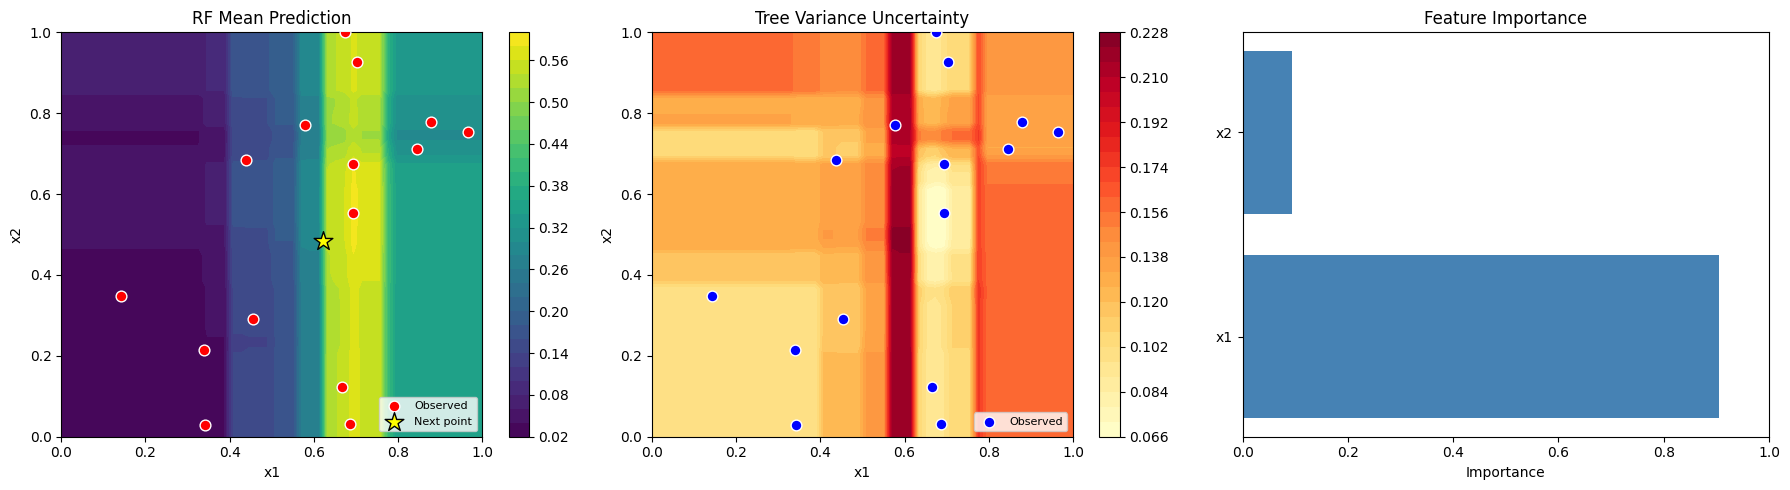

In [5]:
# Create evaluation grid
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# RF predictions and uncertainty on grid
grid_mu = rf_model.predict(grid_points).reshape(n_grid, n_grid)
grid_tree_preds = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
grid_sigma = grid_tree_preds.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RF mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, 0], X_w5[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[0], next_point_w5[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title('RF Mean Prediction')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Tree variance uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, 0], X_w5[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('Tree Variance Uncertainty')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(2)]
ax3.barh(dims, rf_model.feature_importances_, color='steelblue')
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

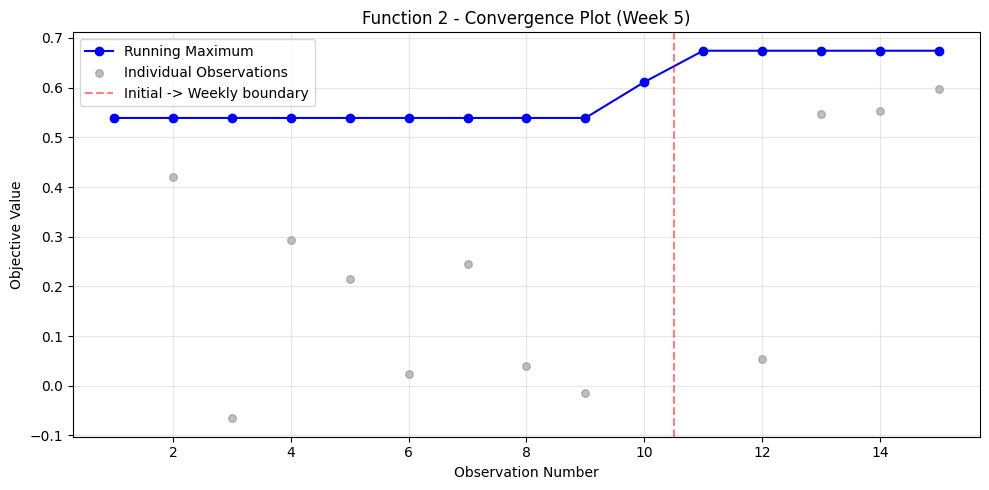

Best observed value: 0.674355
Achieved at observation: 11


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate: Random Forest ({N_ESTIMATORS} trees, max_depth={MAX_DEPTH})")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"OOB Score: {rf_model.oob_score_:.6f}")
print(f"Next point: {next_point_w5}")
print(f"RF prediction: {mu[best_idx]:.6f}")
print(f"Tree uncertainty: {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 2
Surrogate: Random Forest (100 trees, max_depth=5)
Acquisition: UCB (kappa=2.0)
OOB Score: 0.440068
Next point: [0.62267096 0.48447084]
RF prediction: 0.440036
Tree uncertainty: 0.203866

>>> SUBMISSION: 0.622671-0.484471


### Model Comparison

**Random Forest vs GP (Initial Section):**
- The GP model uses a Matern 5/2 kernel with Expected Improvement — it assumes smooth, continuous functions and provides calibrated uncertainty via the posterior distribution.
- The Random Forest makes no smoothness assumptions and builds predictions from decision boundaries. Uncertainty comes from tree disagreement rather than a probabilistic model.
- For f2's log-likelihood estimation problem, RF should capture the moderate-valued landscape well since tree ensembles handle the output range without distributional issues.
- Key trade-off: GP provides better-calibrated uncertainty for UCB, but RF is more robust to non-stationarity in the objective function.

## Week 6 — Random Forest Surrogate

This section continues the Random Forest surrogate from Week 5 with a **reduced exploration parameter** (κ decreased from 2.0 to 0.5) to focus on exploitation.

**Why decrease κ for f2?**
- Week 5's Random Forest achieved a reasonable OOB score, indicating the model has learned f2's landscape
- With 16 data points and a well-fitted model, we shift focus from exploring new regions to exploiting the predicted optimum
- κ=0.5 makes the mean prediction (μ) dominate the acquisition function — the uncertainty term (σ) acts as a small tiebreaker rather than a major driver
- This exploitation strategy aims to refine the best-observed region

**Acquisition Strategy:** UCB with κ=0.5 (exploitation) using tree-variance as uncertainty estimate.

### Step 1: Load Week 6 Data

Load the cumulative Week 6 data (16 total samples = initial 10 + 6 weekly submissions).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f2/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f2/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Input range:  [{X_w6.min():.6f}, {X_w6.max():.6f}]")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed value: {y_w6.max():.6f} at index {y_w6.argmax()}")
print(f"Best observed point: {X_w6[y_w6.argmax()]}")

Week 6 Data: 16 samples, 2 dimensions
Input range:  [0.028698, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]


### Step 2: Random Forest Hyperparameters

**Hyperparameter Choices and Justifications:**

1. **n_estimators = 100**: Same as Week 5. 100 trees provides sufficient ensemble diversity for 16 samples.
2. **max_depth = 5**: Same as Week 5. Prevents overfitting on small dataset.
3. **min_samples_split = 3**, **min_samples_leaf = 2**: Same as Week 5.
4. **random_state = 42**: Fixed seed for reproducibility.
5. **oob_score = True**: Out-of-bag score for validation.
6. **UCB kappa = 0.5**: **Reduced from Week 5's κ=2.0** — strong exploitation focus. The mean prediction now contributes ~2× more than uncertainty to UCB.
7. **n_candidates = 20,000**: Same as Week 5.

In [9]:
# --- Random Forest Hyperparameters ---
N_ESTIMATORS = 100
MAX_DEPTH = 5
MIN_SAMPLES_SPLIT = 3
MIN_SAMPLES_LEAF = 2
RANDOM_STATE = 42
KAPPA = 0.5              # Exploitation focus (Week 5: 2.0 → Week 6: 0.5)
N_CANDIDATES = 20000

print("Random Forest Surrogate Hyperparameters:")
print(f"  n_estimators:      {N_ESTIMATORS}")
print(f"  max_depth:         {MAX_DEPTH}")
print(f"  min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf:  {MIN_SAMPLES_LEAF}")
print(f"  random_state:      {RANDOM_STATE}")
print(f"  oob_score:         True")
print(f"  UCB kappa:         {KAPPA} (Week 5: 2.0 → Week 6: 0.5)")
print(f"  UCB candidates:    {N_CANDIDATES}")

Random Forest Surrogate Hyperparameters:
  n_estimators:      100
  max_depth:         5
  min_samples_split: 3
  min_samples_leaf:  2
  random_state:      42
  oob_score:         True
  UCB kappa:         0.5 (Week 5: 2.0 → Week 6: 0.5)
  UCB candidates:    20000


### Step 3: Train Random Forest Model

Fit the Random Forest on all available Week 6 data. Display the OOB score and feature importance per input dimension.

In [10]:
# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    oob_score=True
)
rf_model.fit(X_w6, y_w6)

# Display results
print("Random Forest Training Results:")
print(f"  OOB Score (R²):  {rf_model.oob_score_:.6f}")
print(f"  Number of trees: {rf_model.n_estimators}")
print()
print("Feature Importance:")
for i, imp in enumerate(rf_model.feature_importances_):
    print(f"  x{i+1}: {imp:.4f} ({'*' * int(imp * 20)})")

Random Forest Training Results:
  OOB Score (R²):  0.518768
  Number of trees: 100

Feature Importance:
  x1: 0.9306 (******************)
  x2: 0.0694 (*)


### Step 4: UCB Acquisition Function

Compute the Upper Confidence Bound using:
- **μ(x)** = mean prediction across all trees (ensemble mean)
- **σ(x)** = standard deviation of individual tree predictions (tree variance)
- **UCB(x) = μ(x) + κ · σ(x)** where κ = 0.5 (exploitation focus)

In [11]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 2))

# Get mean prediction from the ensemble
mu = rf_model.predict(candidates)

# Get uncertainty: std across individual tree predictions
tree_predictions = np.array([tree.predict(candidates) for tree in rf_model.estimators_])
sigma = tree_predictions.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w6 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results:")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  Mean prediction:    {mu[best_idx]:.6f}")
print(f"  Tree std (sigma):   {sigma[best_idx]:.6f}")
print(f"  Exploitation contribution (μ): {mu[best_idx]:.6f}")
print(f"  Exploration contribution (κ·σ): {KAPPA * sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w6}")

UCB Acquisition Results:
  Best UCB value:     0.627090
  Mean prediction:    0.582712
  Tree std (sigma):   0.088758
  Exploitation contribution (μ): 0.582712
  Exploration contribution (κ·σ): 0.044379
  Next sample point:  [0.69172011 0.66134268]


### Step 5: Visualize Random Forest Surrogate

Full 2D contour plot of the RF mean prediction and tree-variance uncertainty over the [0,1]² search space, with feature importance.

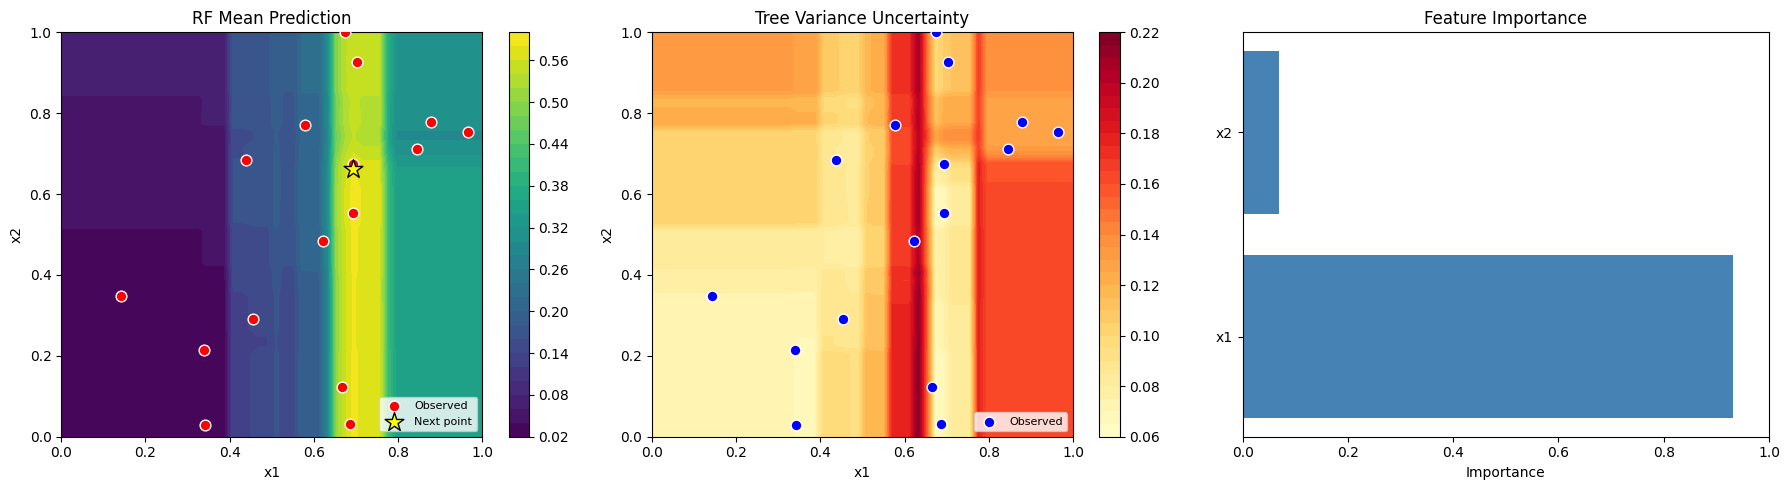

In [12]:
# Create evaluation grid
n_grid = 50
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

# RF predictions and uncertainty on grid
grid_mu = rf_model.predict(grid_points).reshape(n_grid, n_grid)
grid_tree_preds = np.array([tree.predict(grid_points) for tree in rf_model.estimators_])
grid_sigma = grid_tree_preds.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RF mean prediction
ax1 = axes[0]
c1 = ax1.contourf(X1, X2, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w6[:, 0], X_w6[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w6[0], next_point_w6[1], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
ax1.set_title('RF Mean Prediction')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: Tree variance uncertainty
ax2 = axes[1]
c2 = ax2.contourf(X1, X2, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w6[:, 0], X_w6[:, 1], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
ax2.set_title('Tree Variance Uncertainty')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(2)]
ax3.barh(dims, rf_model.feature_importances_, color='steelblue')
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance')
ax3.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all 16 observations.

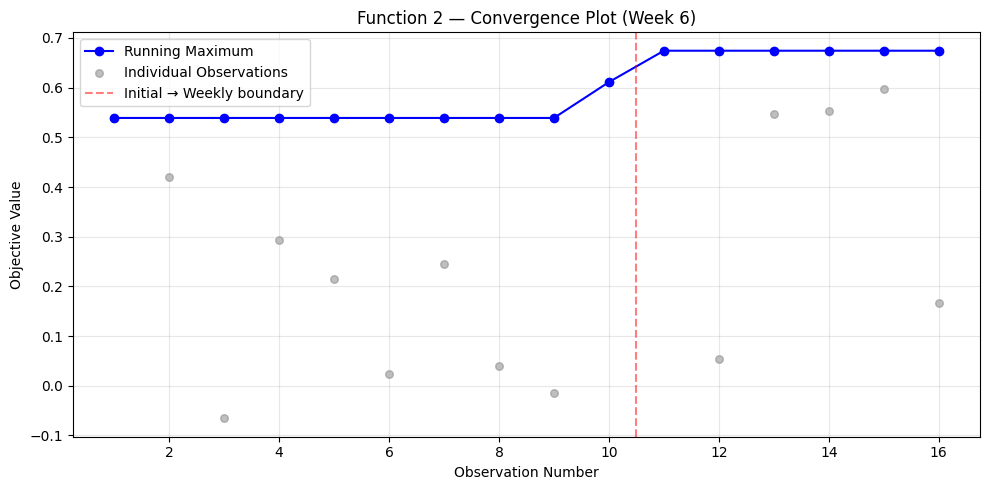

Best observed value: 0.674355
Achieved at observation: 11


In [13]:
# Convergence plot
running_max = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w6) + 1), y_w6, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 6)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w6.max():.6f}")
print(f"Achieved at observation: {y_w6.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places, clamped to [0.0, 1.0].

In [14]:
# Format submission query
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0.0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w6 = format_query(next_point_w6)

print("=" * 60)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate: Random Forest ({N_ESTIMATORS} trees, max_depth={MAX_DEPTH})")
print(f"Acquisition: UCB (κ={KAPPA})")
print(f"Strategy: EXPLOITATION (κ reduced from 2.0 to 0.5)")
print(f"OOB Score: {rf_model.oob_score_:.6f}")
print(f"Next point: {next_point_w6}")
print(f"RF prediction: {mu[best_idx]:.6f}")
print(f"Tree uncertainty: {sigma[best_idx]:.6f}")
print(f"\n>>> SUBMISSION: {submission_query_w6}")
print("=" * 60)

WEEK 6 SUBMISSION QUERY FOR FUNCTION 2
Surrogate: Random Forest (100 trees, max_depth=5)
Acquisition: UCB (κ=0.5)
Strategy: EXPLOITATION (κ reduced from 2.0 to 0.5)
OOB Score: 0.518768
Next point: [0.69172011 0.66134268]
RF prediction: 0.582712
Tree uncertainty: 0.088758

>>> SUBMISSION: 0.691720-0.661343
